In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [35]:
columns_name = ["engine_id", "cycle", "setting_1", "setting_2", "setting_3", 
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20",
    "sensor_21"
]

df = pd.read_csv("../data/CMAPSSData/train_FD001.txt", sep=r"\s+", header=None, names=columns_name)

print(df.head())

   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

In [36]:
print(df.shape)
print(df.columns.tolist())

(20631, 26)
['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [37]:
datasets = {}

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    path = f"../data/CMAPSSData/train_{fd}.txt"

    datasets[fd] = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=columns_name
    )

In [38]:
print(datasets["FD001"].head())

   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

In [39]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
num_engines = df["engine_id"].nunique()

print("Number of engines:", num_engines)

Number of engines: 100


In [42]:
cycles_per_engine = df.groupby("engine_id")["cycle"].max()

print(cycles_per_engine)

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


In [43]:
print(cycles_per_engine.describe())

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


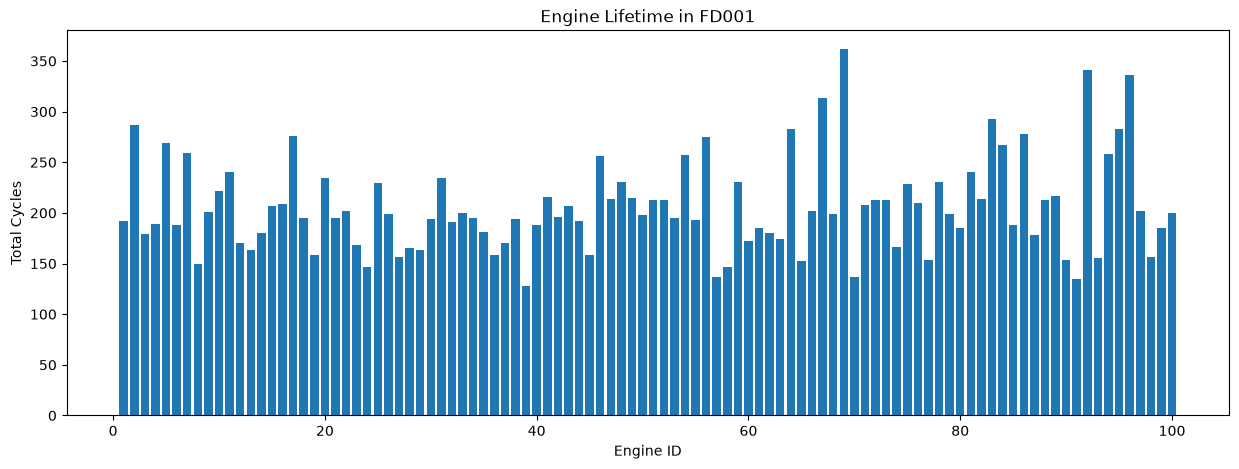

In [44]:
plt.figure(figsize=(15, 5))

plt.bar(cycles_per_engine.index, cycles_per_engine.values)

plt.xlabel("Engine ID")
plt.ylabel("Total Cycles")
plt.title("Engine Lifetime in FD001")
plt.show()

In [45]:
sensor_columns = []

for col in df.columns:
    if col.startswith("sensor_"):
        sensor_columns.append(col)


print(sensor_columns)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [46]:
setting_columns = []

for col in df.columns:
    if col.startswith("setting_"):
        setting_columns.append(col)

print(setting_columns)

['setting_1', 'setting_2', 'setting_3']


In [47]:
sensor_stats = df[sensor_columns].describe().T

sensor_stats

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


In [48]:
sensor_variance = df[sensor_columns].var().sort_values()

print(sensor_variance)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


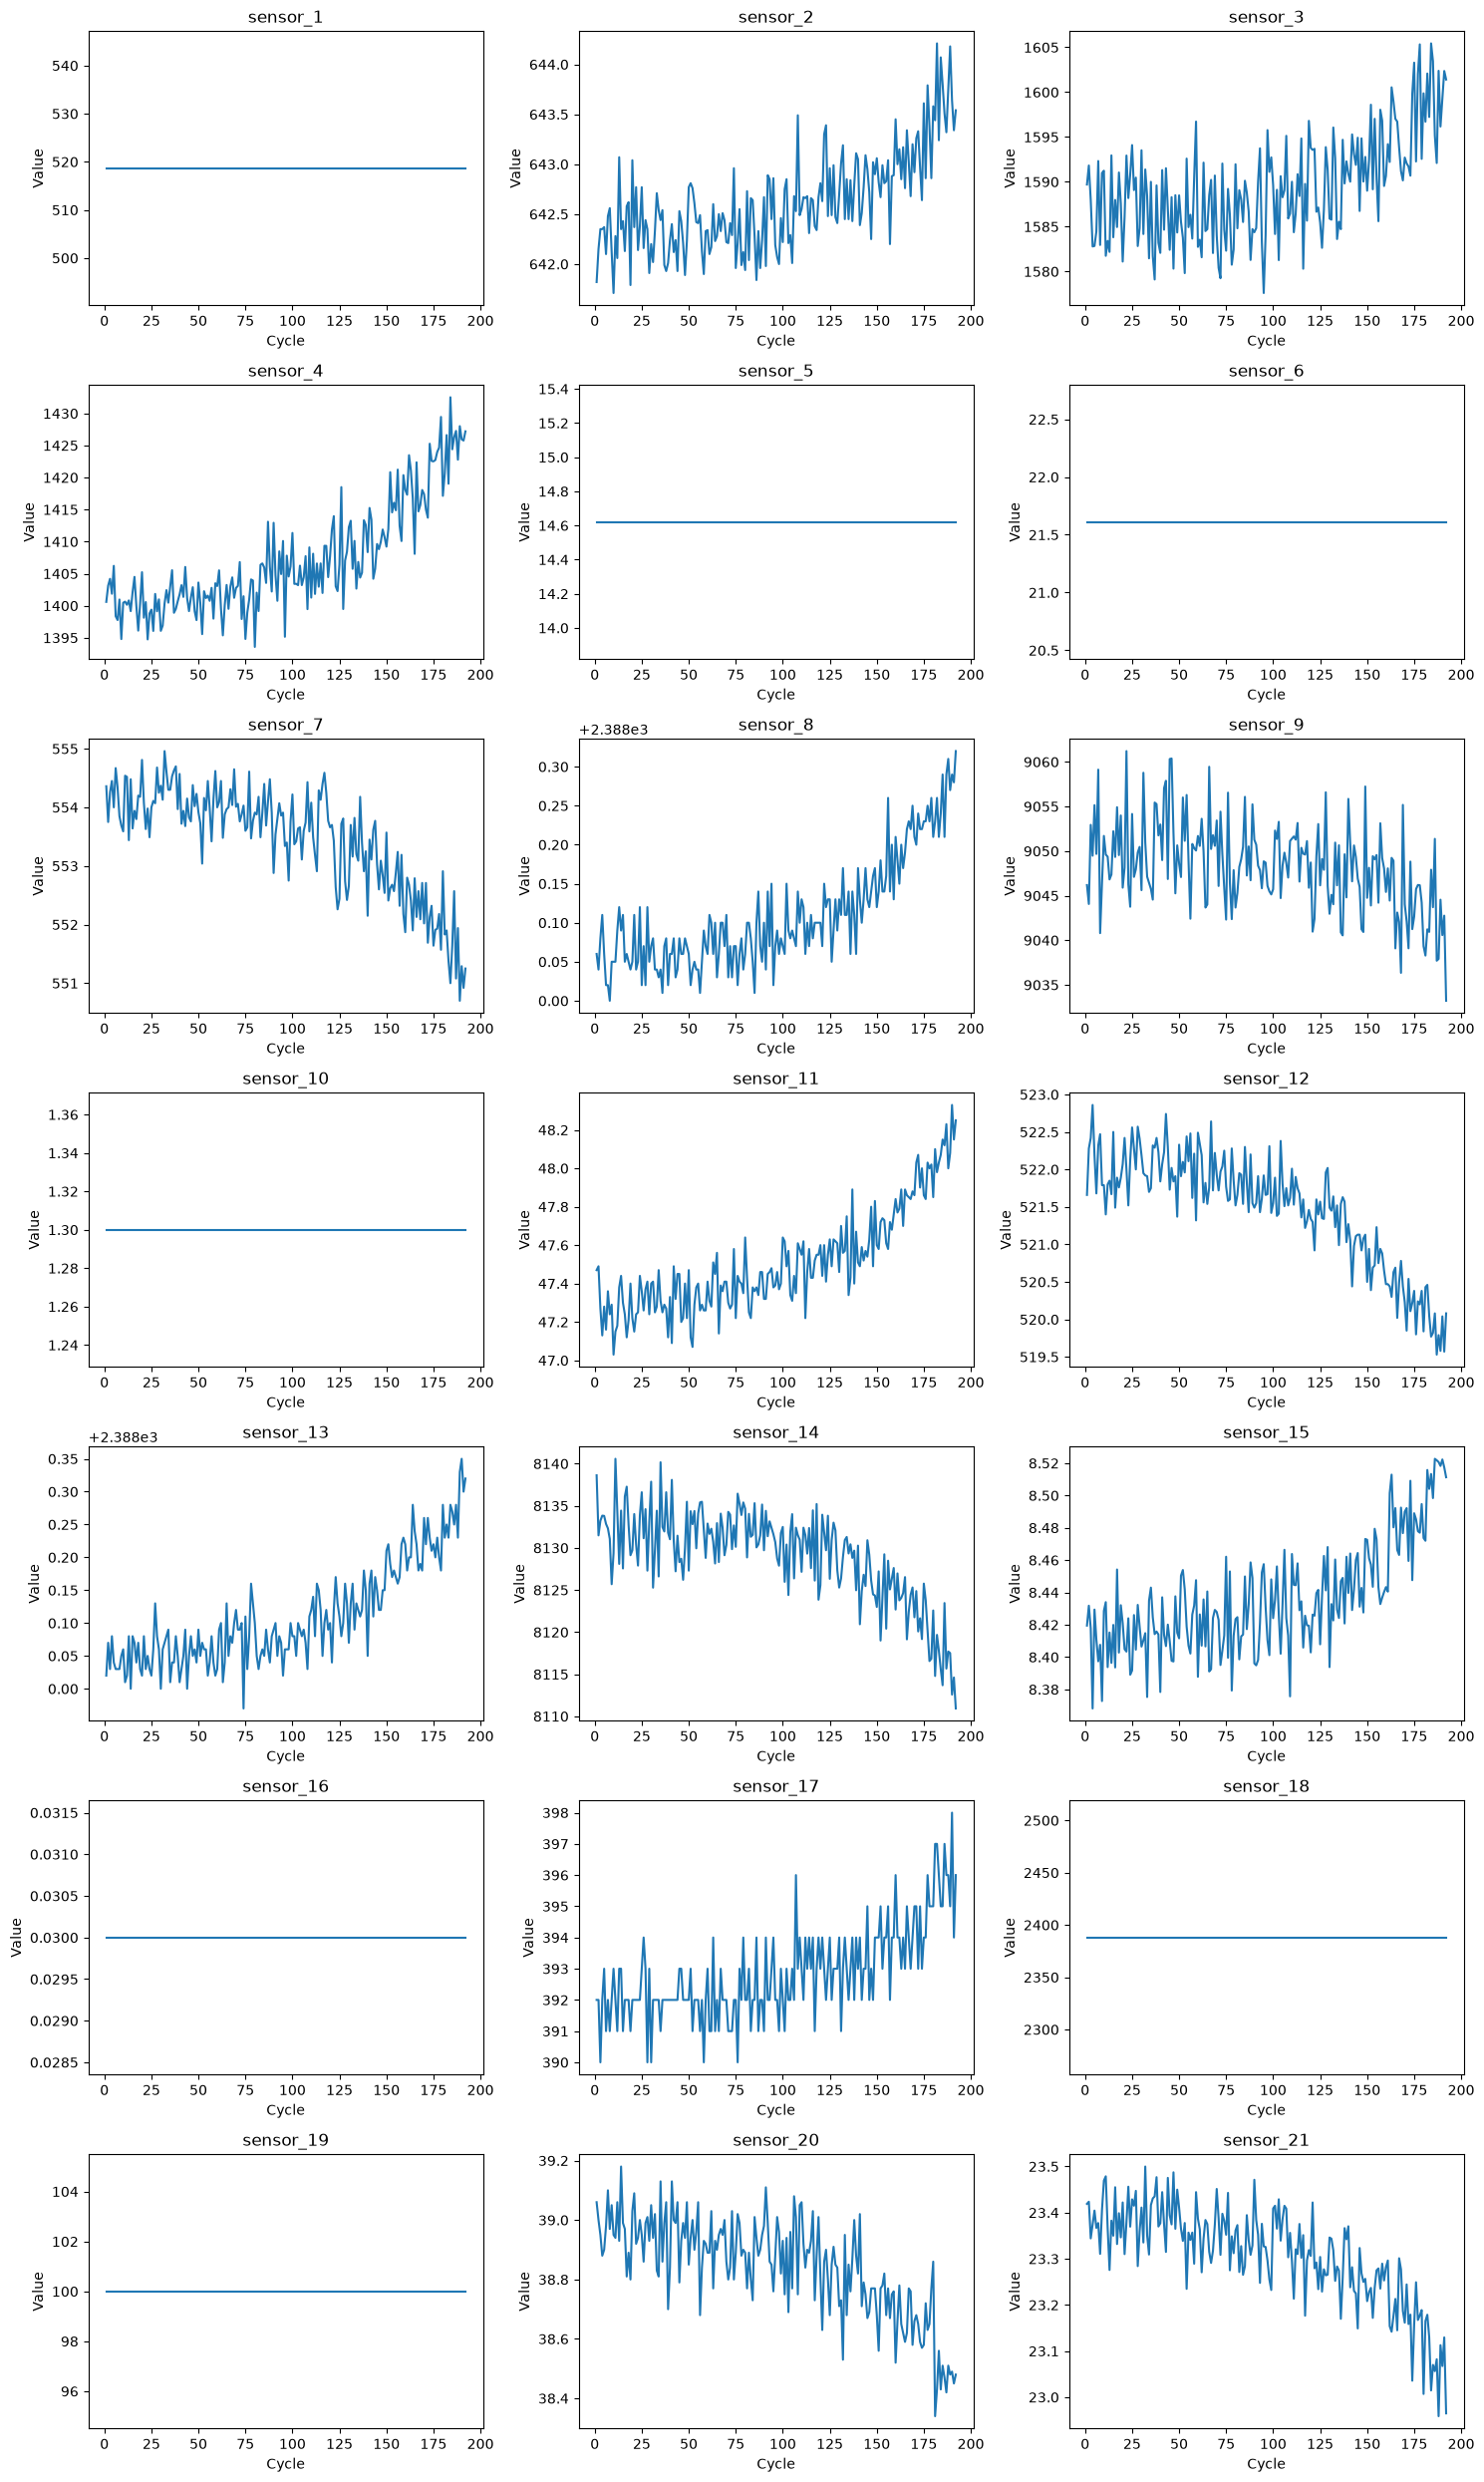

In [49]:
fig, axes = plt.subplots(7, 3, figsize=(15, 25))

engine_1 = df[df["engine_id"] == 1]

for i, sensor in enumerate(sensor_columns):
    ax = axes.flat[i]

    ax.plot(engine_1["cycle"], engine_1[sensor])

    ax.set_title(sensor)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [50]:
for setting in setting_columns:
    print(setting, "unique values:", df[setting].nunique())

setting_1 unique values: 158
setting_2 unique values: 13
setting_3 unique values: 1


In [51]:
constant_sensors = []

for sensor in sensor_columns:
    if df[sensor].nunique() <= 1:
        constant_sensors.append(sensor)

print(constant_sensors)


for sensor in constant_sensors:
    print(sensor, "unique:", df[sensor].nunique(), "variance:", df[sensor].var())

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
sensor_1 unique: 1 variance: 0.0
sensor_5 unique: 1 variance: 2.840036917509108e-29
sensor_10 unique: 1 variance: 0.0
sensor_16 unique: 1 variance: 1.203764562610672e-35
sensor_18 unique: 1 variance: 0.0
sensor_19 unique: 1 variance: 0.0


In [52]:
df = df.drop(columns=constant_sensors)

In [53]:
rem_sensor_columns = []

for col in df.columns:
    if col.startswith("sensor_"):
        rem_sensor_columns.append(col)


print("Remaining sensors:")
print(rem_sensor_columns)

Remaining sensors:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [54]:
max_cycle = df.groupby("engine_id")["cycle"].transform("max")

df["RUL"] = max_cycle - df["cycle"]

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [55]:
df["failure"] = (df["RUL"] <= 30).astype(int)

In [56]:
from sklearn.model_selection import train_test_split

engine_ids = df["engine_id"].unique()

train_engines, test_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)

train_df = df[df["engine_id"].isin(train_engines)].copy()
test_df = df[df["engine_id"].isin(test_engines)].copy()

print("Training engines:", len(train_engines))
print("Testing engines:", len(test_engines))

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training engines: 80
Testing engines: 20
Training shape: (16561, 22)
Testing shape: (4070, 22)


In [57]:
scaler = StandardScaler()

train_df[rem_sensor_columns] = scaler.fit_transform(train_df[rem_sensor_columns])

test_df[rem_sensor_columns] = scaler.transform(test_df[rem_sensor_columns])

print("Training means:")
print(train_df[rem_sensor_columns].mean().round(3))

print("\nTraining standard deviations:")
print(train_df[rem_sensor_columns].std().round(3))

Training means:
sensor_2    -0.0
sensor_3    -0.0
sensor_4    -0.0
sensor_6    -0.0
sensor_7    -0.0
sensor_8    -0.0
sensor_9     0.0
sensor_11   -0.0
sensor_12    0.0
sensor_13    0.0
sensor_14    0.0
sensor_15   -0.0
sensor_17   -0.0
sensor_20   -0.0
sensor_21    0.0
dtype: float64

Training standard deviations:
sensor_2     1.0
sensor_3     1.0
sensor_4     1.0
sensor_6     1.0
sensor_7     1.0
sensor_8     1.0
sensor_9     1.0
sensor_11    1.0
sensor_12    1.0
sensor_13    1.0
sensor_14    1.0
sensor_15    1.0
sensor_17    1.0
sensor_20    1.0
sensor_21    1.0
dtype: float64


In [58]:
WINDOW_SIZE = 30


def create_windows(data, sensor_columns, WINDOW_SIZE):
    
    X = []
    y_rul = []
    y_failure = []

    for engine_id, engine_data in data.groupby("engine_id"):

        engine_data = engine_data.sort_values("cycle")

        sensor_values = engine_data[sensor_columns].values
        rul_values = engine_data["RUL"].values
        failure_values = engine_data["failure"].values

        for i in range(len(engine_data) - WINDOW_SIZE + 1):

            X.append(sensor_values[i:i + WINDOW_SIZE])

            y_rul.append(rul_values[i + WINDOW_SIZE - 1])

            y_failure.append(failure_values[i + WINDOW_SIZE - 1])

    return (np.array(X), np.array(y_rul), np.array(y_failure))

In [59]:
X_test, y_rul_test, y_failure_test = create_windows(test_df, rem_sensor_columns, WINDOW_SIZE)

print("X_test shape:", X_test.shape)
print("RUL test shape:", y_rul_test.shape)
print("Failure test shape:", y_failure_test.shape)

X_test shape: (3490, 30, 15)
RUL test shape: (3490,)
Failure test shape: (3490,)


In [62]:
X_train, y_rul_train, y_failure_train = create_windows(train_df, rem_sensor_columns, WINDOW_SIZE)

print("X_train shape:", X_train.shape)
print("RUL train shape:", y_rul_train.shape)
print("Failure train shape:", y_failure_train.shape)

X_train shape: (14241, 30, 15)
RUL train shape: (14241,)
Failure train shape: (14241,)


In [ ]:
import numpy as np

np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/y_rul_train.npy", y_rul_train)

np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/y_rul_test.npy", y_rul_test)


np.save("../data/processed/y_failure_train.npy", y_failure_train)
np.save("../data/processed/y_failure_test.npy", y_failure_test)